# Single Neuron Regression Analysis :)

In [83]:
import os

from analyses.data_loader import explode_spike_data
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [101]:
significant_results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/directional_linear_regression_on_single_neurons_zscored_beh_mat.pkl')
significant_results = significant_results[significant_results['p_value'] < 0.05]
print(significant_results.shape)
print(significant_results['NeuronID'].nunique())

(1583, 7)
490


In [102]:
significant_results.tail()

,NeuronID,Behavior,Source_Monkey,Model,R-squared,coef,p_value
5414,AMG_2023-09-29_3_Channel.C_005_Unit 1,AffliationFrom,7124,ols,0.950340,1.155508,3.900469e-05
25327,AMG_2023-10-03_3_Channel.C_026_Unit 2,AgonismFrom,151J,ols,0.951718,0.937866,3.582811e-05
19496,Unknown_2023-12-18_3_Channel.C_020_Unit 1,SubmissionFrom,110E,ols,0.961136,0.868522,1.861811e-05
10187,AMG_2023-09-29_2_Channel.C_011_Unit 2,SubmissionTo,67G,ols,0.968002,16.178034,1.036364e-05
19504,Unknown_2023-12-18_3_Channel.C_020_Unit 2,SubmissionFrom,110E,ols,1.000000,18.442407,4.681676e-96


## Simple Visualization

### Heatmap

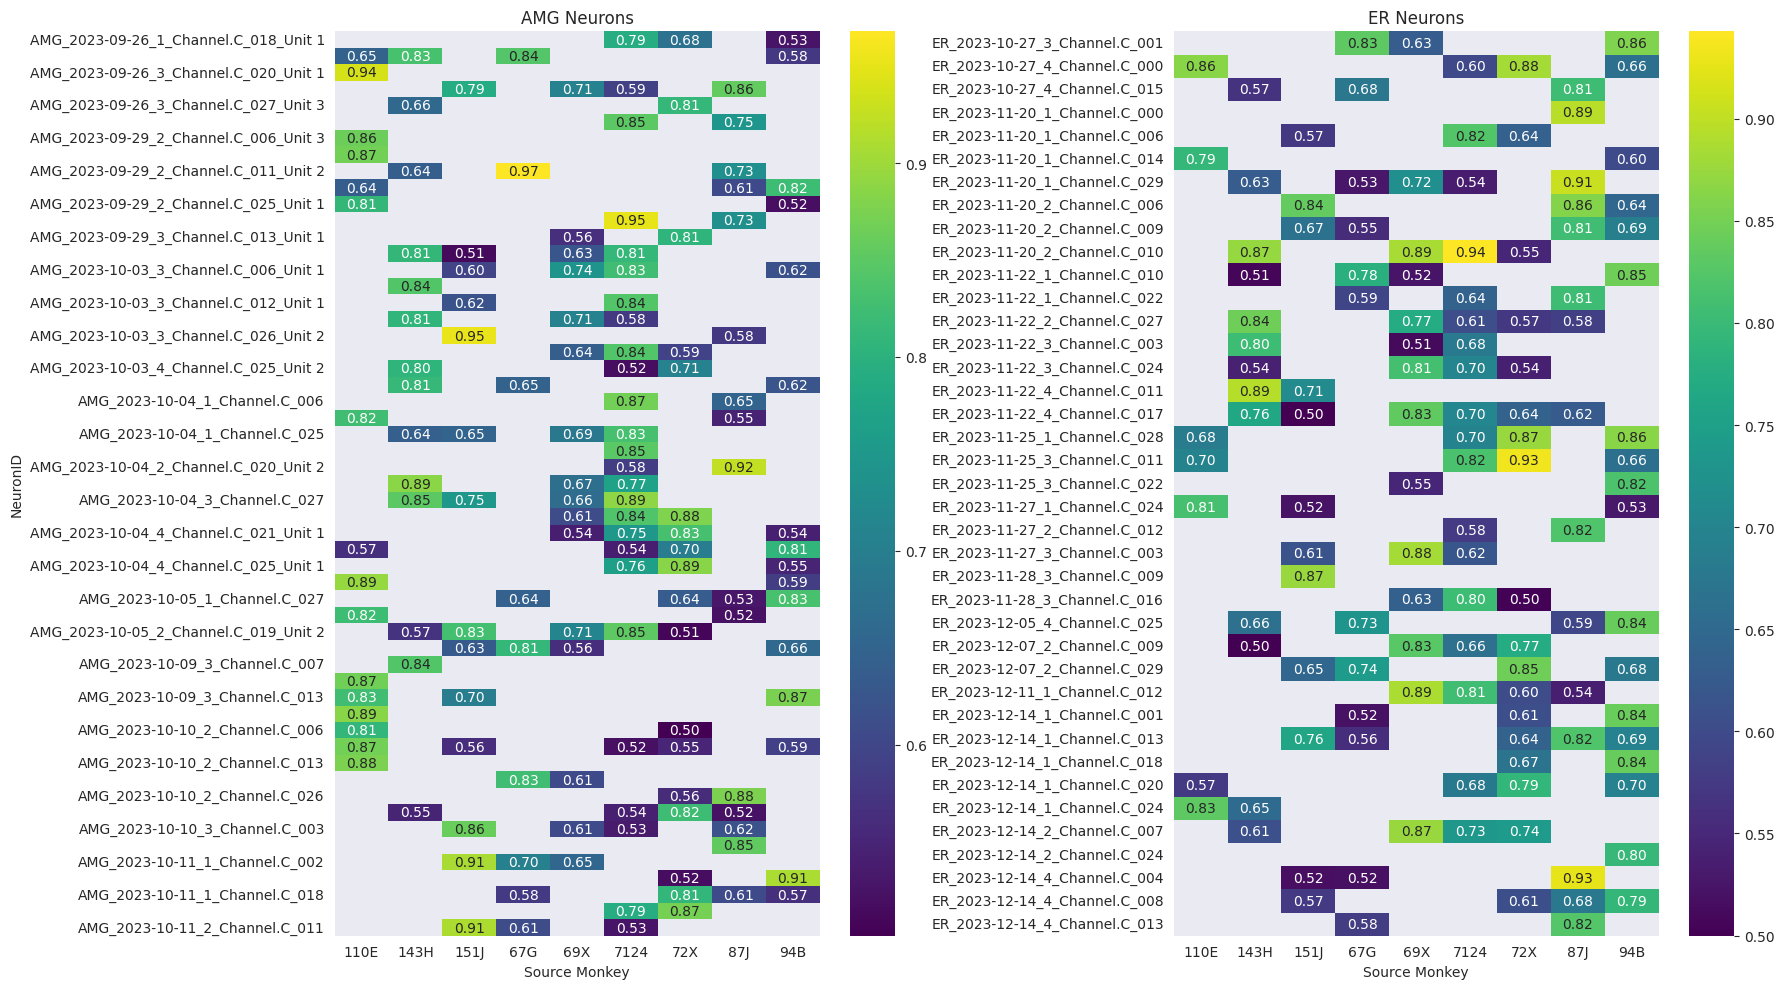

In [103]:
top_n = 100  # 또는 10~15
top_neurons = significant_results.groupby('NeuronID')['R-squared'].max().nlargest(top_n).index
filtered_df = significant_results[significant_results['NeuronID'].isin(top_neurons)]
amg_df = filtered_df[filtered_df['NeuronID'].str.startswith('AMG')]
er_df = filtered_df[filtered_df['NeuronID'].str.startswith('ER')]

fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharex=True)

# AMG
heatmap_amg = amg_df.pivot_table(index='NeuronID', columns='Source_Monkey', values='R-squared', aggfunc='max')
sns.heatmap(heatmap_amg, cmap='viridis', annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("AMG Neurons")
axes[0].set_xlabel("Source Monkey")
axes[0].set_ylabel("NeuronID")

# ER
heatmap_er = er_df.pivot_table(index='NeuronID', columns='Source_Monkey', values='R-squared', aggfunc='max')
sns.heatmap(heatmap_er, cmap='viridis', annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("ER Neurons")
axes[1].set_xlabel("Source Monkey")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [104]:
significant_results['Behavior'].value_counts()

Behavior
AgonismTo         280
AffliationFrom    270
SubmissionFrom    270
AffliationTo      264
SubmissionTo      253
AgonismFrom       246
Name: count, dtype: int64

In [105]:
significant_results['Source_Monkey'].value_counts()

Source_Monkey
7124    192
69X     192
72X     188
87J     181
110E    180
151J    168
67G     167
143H    159
94B     156
Name: count, dtype: int64

### Count Plot

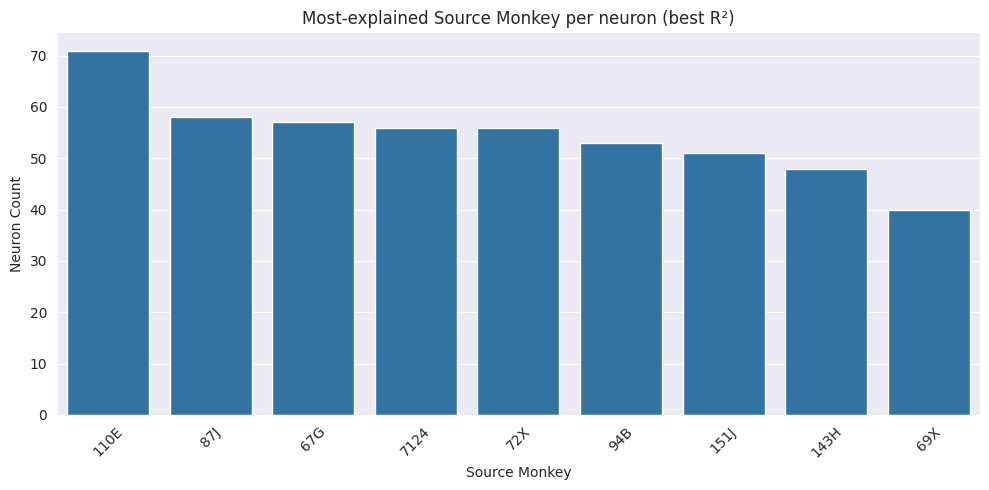

In [106]:
best_monkey_df = significant_results.sort_values('R-squared', ascending=False).drop_duplicates('NeuronID')
plt.figure(figsize=(10, 5))
sns.countplot(data=best_monkey_df, x='Source_Monkey', order=best_monkey_df['Source_Monkey'].value_counts().index)
plt.title("Most-explained Source Monkey per neuron (best R²)")
plt.xlabel("Source Monkey")
plt.ylabel("Neuron Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

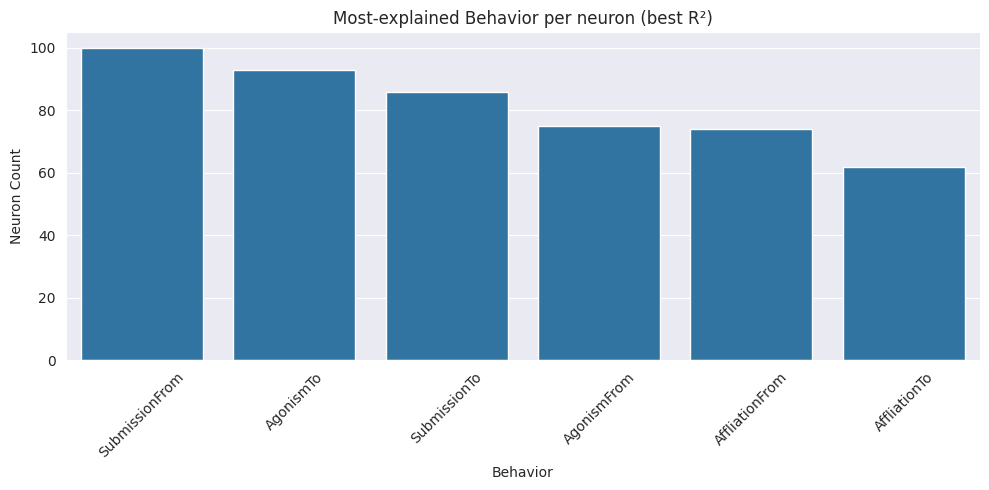

In [107]:
### Count Plot
best_behavior_df = significant_results.sort_values('R-squared', ascending=False).drop_duplicates('NeuronID')
plt.figure(figsize=(10, 5))
sns.countplot(data=best_monkey_df, x='Behavior', order=best_behavior_df['Behavior'].value_counts().index)
plt.title("Most-explained Behavior per neuron (best R²)")
plt.xlabel("Behavior")
plt.ylabel("Neuron Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of Coefficients

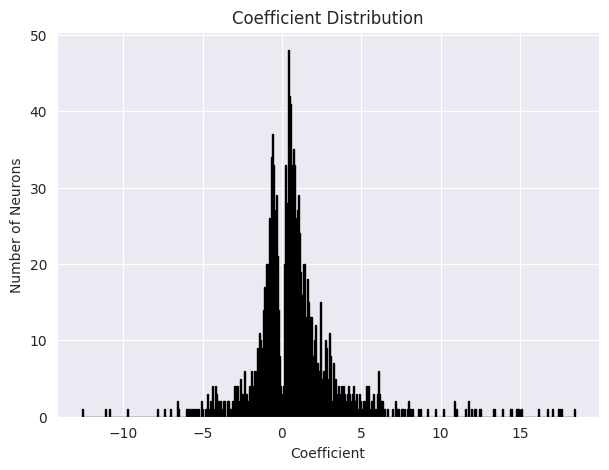

In [108]:
# Coefficient distribution
plt.figure(figsize=(7, 5))
plt.hist(significant_results['coef'], bins=500, edgecolor='black')
plt.title('Coefficient Distribution')
plt.xlabel('Coefficient')
plt.ylabel('Number of Neurons')
plt.grid(True)
plt.show()

### Distribution of R-squared values

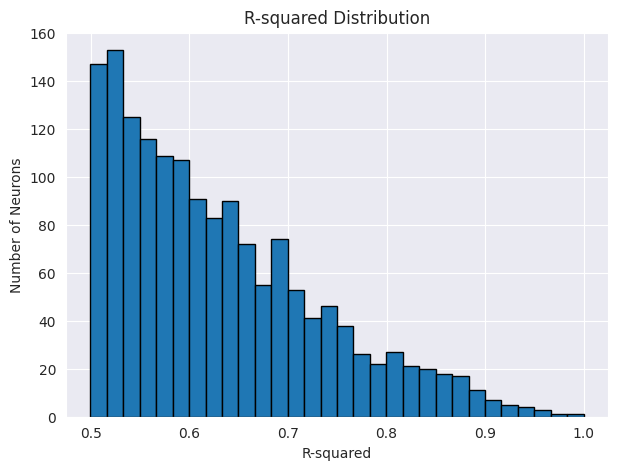

In [109]:
# R-squared distribution
plt.figure(figsize=(7, 5))
plt.hist(significant_results['R-squared'].dropna(), bins=30, edgecolor='black')  # dropna() just in case
plt.title('R-squared Distribution')
plt.xlabel('R-squared')
plt.ylabel('Number of Neurons')
plt.grid(True)
plt.show()

## Boxplot Behavior

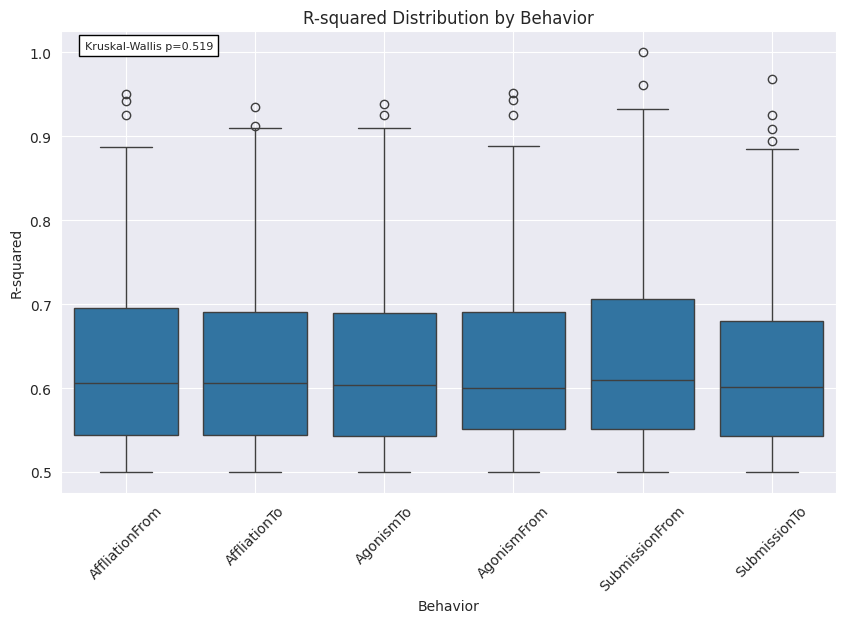

In [110]:
# Box Plot
from scipy.stats import kruskal

# 1. Kruskal-Wallis Test (behavior)
groups = [group['R-squared'].values for name, group in significant_results.groupby('Behavior')]
stat, p = kruskal(*groups)

# 2. Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Behavior',
    y='R-squared',
    data=significant_results,
)
plt.title('R-squared Distribution by Behavior')
plt.xlabel('Behavior')
plt.ylabel('R-squared')
plt.xticks(rotation=45)
plt.grid(True)

# 3. Add text with p-value
plt.text(
    0.03, 0.98,
    f'Kruskal-Wallis p={p:.3f}',
    horizontalalignment='left',
    verticalalignment='top',
    transform=plt.gca().transAxes,
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.show()

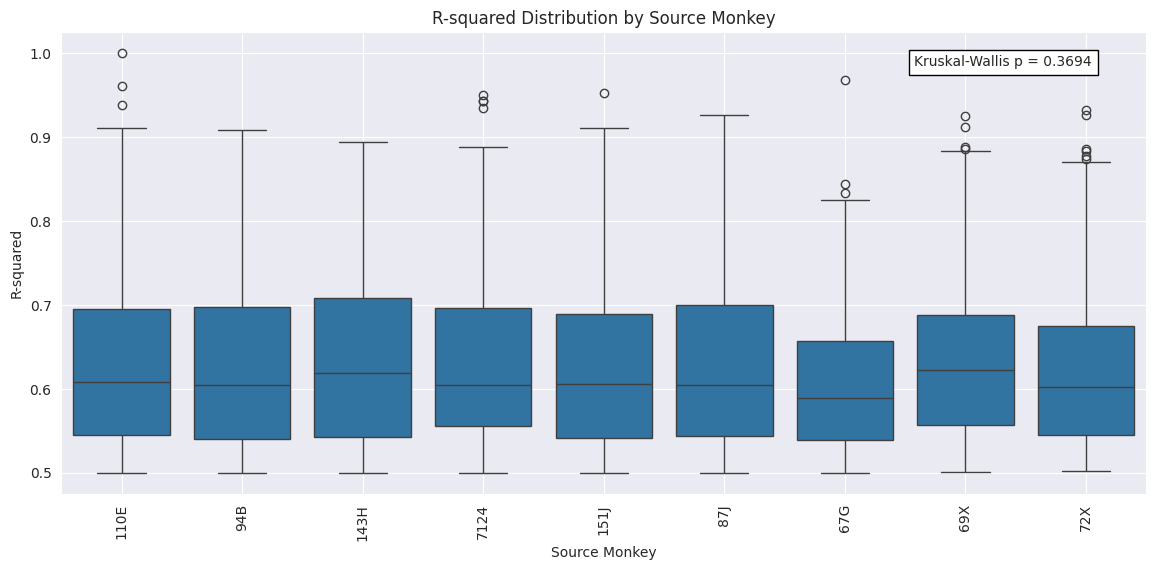

In [111]:
# 1. Kruskal-Wallis Test (Source_Monkey 기준)
groups = [group['R-squared'].values for name, group in significant_results.groupby('Source_Monkey')]
stat, p = kruskal(*groups)

# 2. Boxplot
plt.figure(figsize=(14, 6))  # Monkey가 많으니까 width 넓힘
sns.boxplot(
    x='Source_Monkey',
    y='R-squared',
    data=significant_results,
)
plt.title('R-squared Distribution by Source Monkey')
plt.xlabel('Source Monkey')
plt.ylabel('R-squared')
plt.xticks(rotation=90)
plt.grid(True)

# 3. Add p-value to upper right corner
plt.text(
    0.95, 0.95,
    f'Kruskal-Wallis p = {p:.4f}',
    horizontalalignment='right',
    verticalalignment='top',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.show()

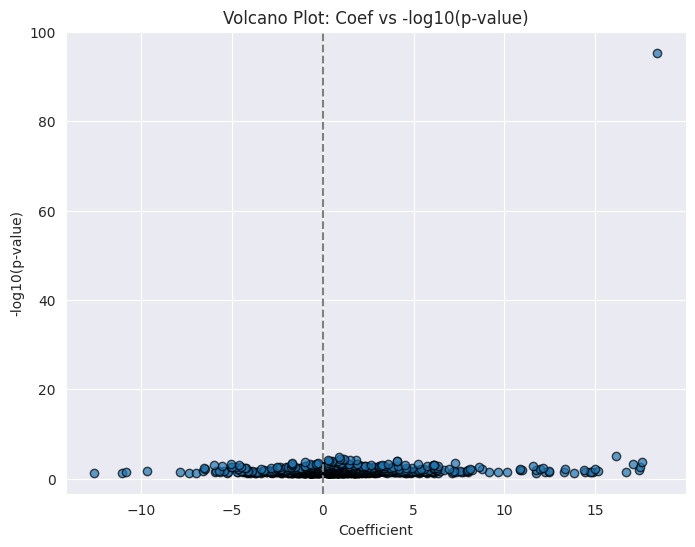

In [113]:
significant_results['neg_log10_p'] = -np.log10(significant_results['p_value'])

plt.figure(figsize=(8,6))
plt.scatter(
    significant_results['coef'],
    significant_results['neg_log10_p'],
    alpha=0.7,
    edgecolors='k'
)
plt.title('Volcano Plot: Coef vs -log10(p-value)')
plt.xlabel('Coefficient')
plt.ylabel('-log10(p-value)')
plt.grid(True)
plt.axvline(x=0, color='gray', linestyle='--')  # 0 기준선
plt.show()

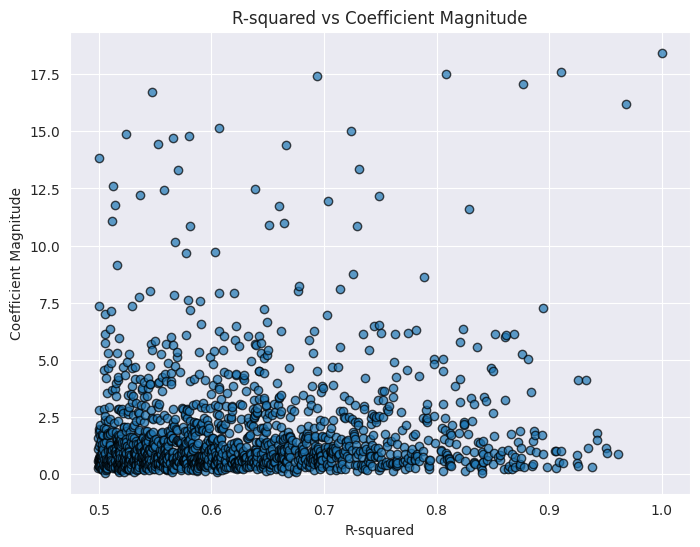

In [114]:
filtered = significant_results[np.abs(significant_results['coef']) < 100]
plt.figure(figsize=(8,6))
plt.scatter(
    significant_results['R-squared'],
    np.abs(significant_results['coef']) ,  # Coef magnitude (절댓값)
    alpha=0.7,
    edgecolors='k'
)
plt.title('R-squared vs Coefficient Magnitude')
plt.xlabel('R-squared')
plt.ylabel('Coefficient Magnitude')
plt.grid(True)
plt.show()

# Representing each neuron as 54-dimensional vector
6 behaviors x 9 source monkeys
(not all of these r-squared values would be p-value with < 0.05 (so they probably didn't pass the filtering) so they would just be 0 here)

In [115]:
# Step 1: 먼저 전체 significant result를 behavior × source_monkey 조합으로 정리
filtered_df = significant_results.sort_values('R-squared', ascending=False)
# Step 2: pivot (NeuronID × [Behavior|SourceMonkey] 조합 → column 이름을 합쳐서 사용)
filtered_df['Behavior_Source'] = filtered_df['Behavior'] + '__' + filtered_df['Source_Monkey']
filtered_df['NeuronID'].nunique()

490

In [116]:
pivot_df = filtered_df.pivot(index='NeuronID', columns='Behavior_Source', values='R-squared').fillna(0)

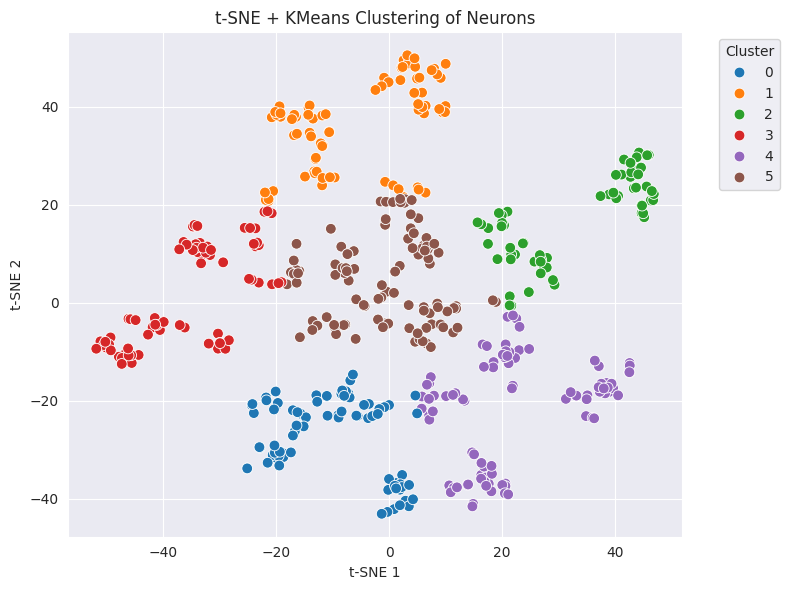

In [117]:
# Scaling
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(pivot_df)

# t-sne
tsne = TSNE(n_components=2, perplexity=10, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(pivot_df)

# KMeans clustering
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


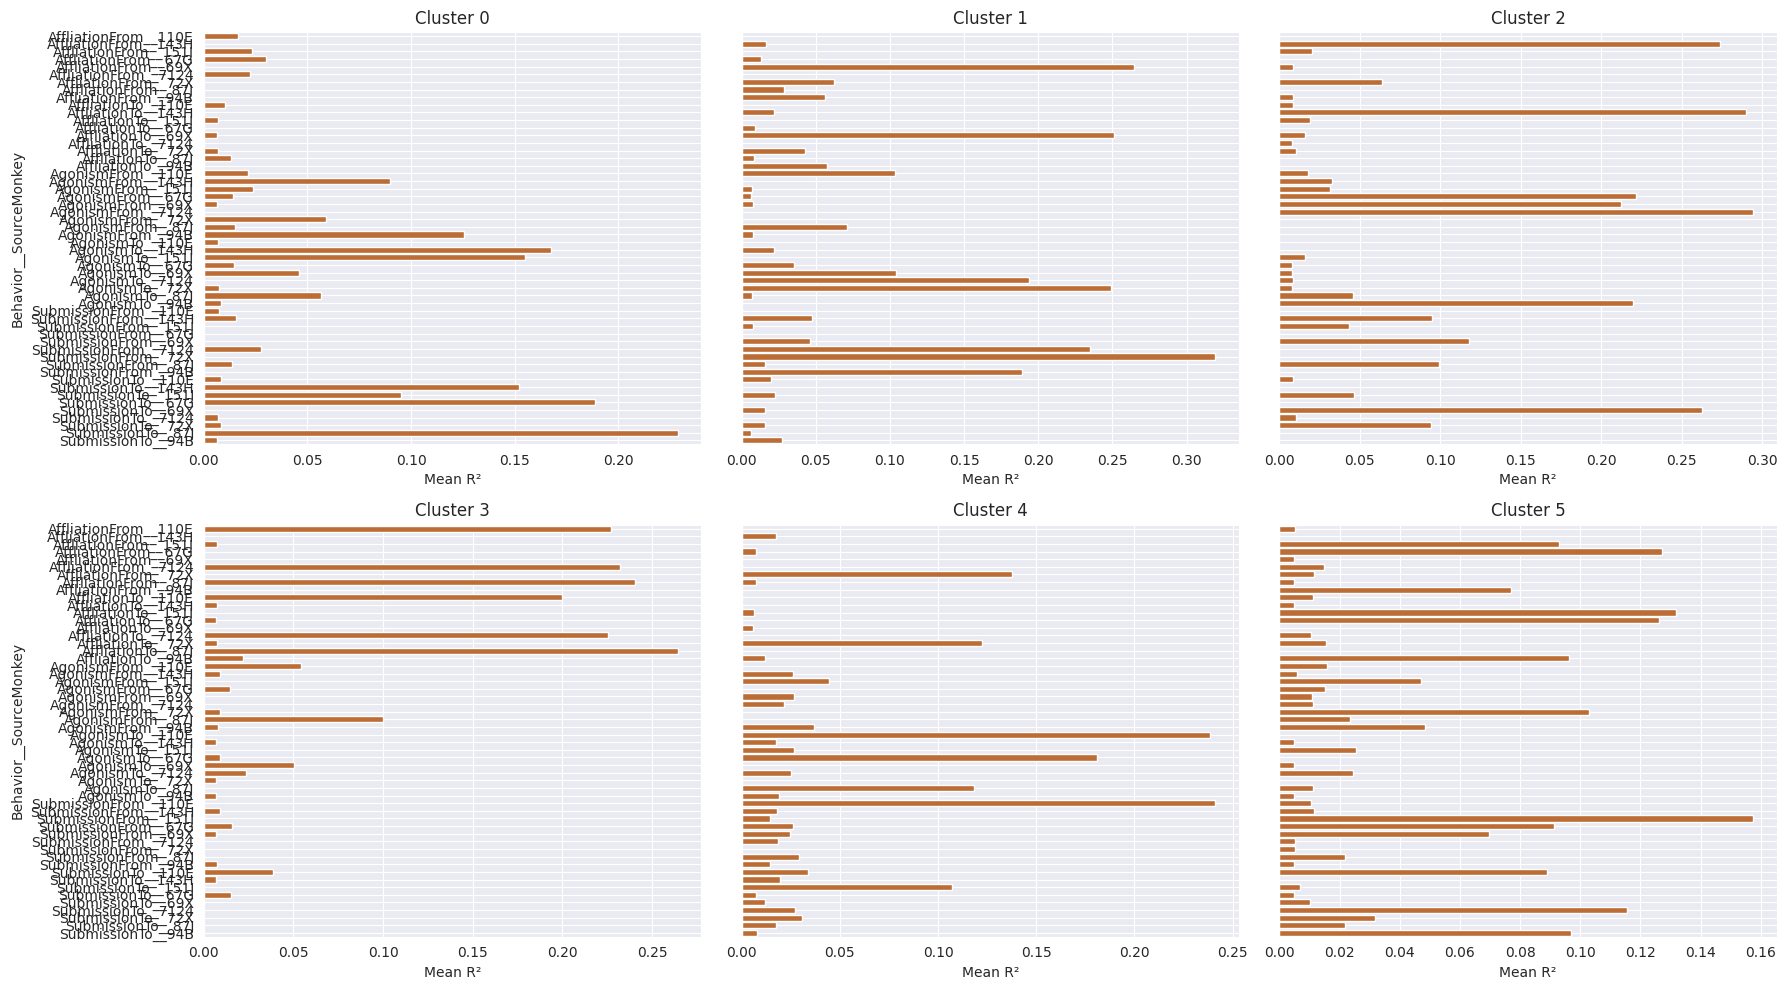

In [44]:
# %matplotlib tk
# pivot_df: NeuronID × Behavior_Source
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels

n_clusters = pivot_df_clustered['Cluster'].nunique()

ncols = 3
nrows = (n_clusters + ncols - 1) // ncols  # 자동 계산

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharey=True)

axes = axes.flatten()

for i, cluster_id in enumerate(sorted(pivot_df_clustered['Cluster'].unique())):
    ax = axes[i]

    cluster_df = pivot_df_clustered[pivot_df_clustered['Cluster'] == cluster_id].drop(columns='Cluster')
    mean_r2 = cluster_df.mean()
    mean_r2 = mean_r2.sort_index(ascending=True)

    sns.barplot(x=mean_r2.values, y=mean_r2.index, ax=ax, color='chocolate')
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Mean R²")
    if i % ncols == 0:
        ax.set_ylabel("Behavior__SourceMonkey")
    else:
        ax.set_ylabel("")
    ax.grid(True)

# delete remaining empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

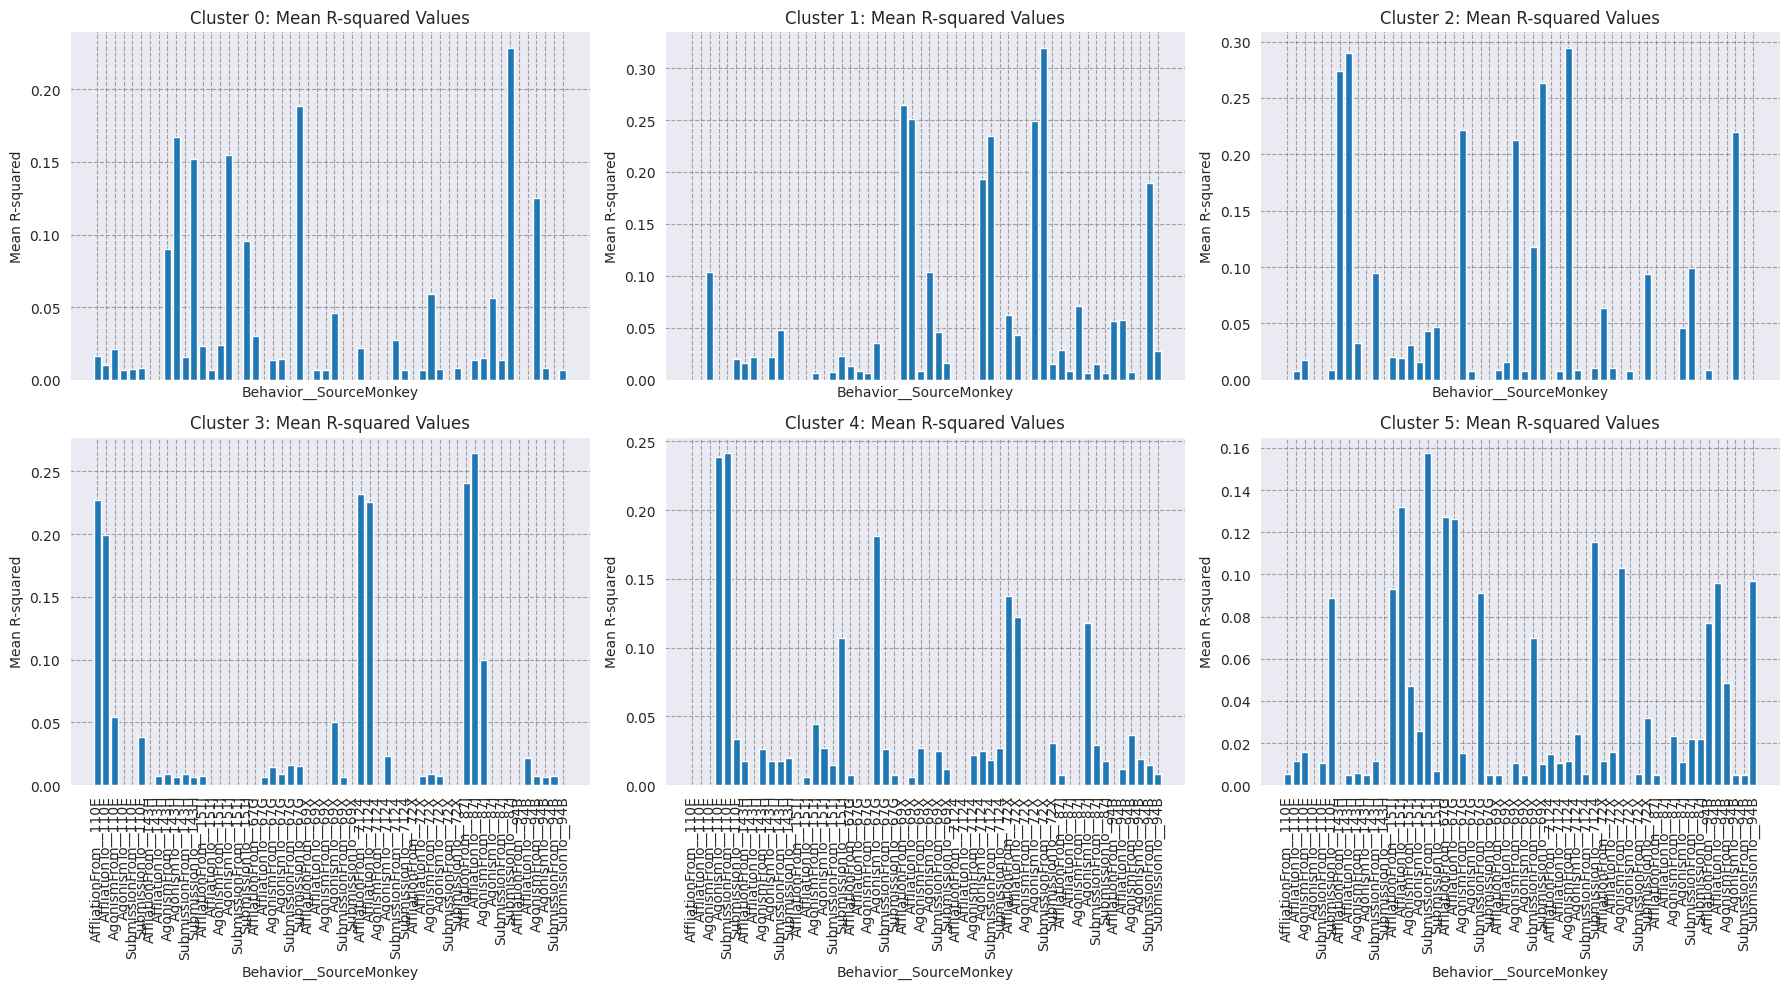

In [45]:
# %matplotlib tk
# Step 1: pivot_df에 cluster label 붙이기
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels

# Step 2: Cluster별로 평균 R-squared 값 계산
mean_r2_by_cluster = pivot_df_clustered.groupby('Cluster').mean()

# Step 3: Column 정렬 순서 정의
col_split = mean_r2_by_cluster.columns.str.split('__', expand=True)
col_split_df = pd.DataFrame(col_split.tolist(), columns=['Behavior', 'SourceMonkey'])
sorted_columns = col_split_df.sort_values(['SourceMonkey', 'Behavior']).apply(lambda x: f"{x['Behavior']}__{x['SourceMonkey']}", axis=1)

# Step 4: sort columns
mean_r2_by_cluster = mean_r2_by_cluster[sorted_columns]

n_clusters = mean_r2_by_cluster.shape[0]
ncols = 3
nrows = (n_clusters + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*6, nrows*5), sharex=True)

axes = axes.flatten()

for i, cluster_id in enumerate(sorted(mean_r2_by_cluster.index)):
    ax = axes[i]
    ax.bar(mean_r2_by_cluster.columns, mean_r2_by_cluster.loc[cluster_id])
    ax.set_title(f"Cluster {cluster_id}: Mean R-squared Values", fontsize=12)
    ax.set_ylabel("Mean R-squared", fontsize=10)
    ax.set_xlabel("Behavior__SourceMonkey", fontsize=10)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(True, axis='both', linestyle='--', color='gray', alpha=0.7)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Do PCA to reduce the dimensions first

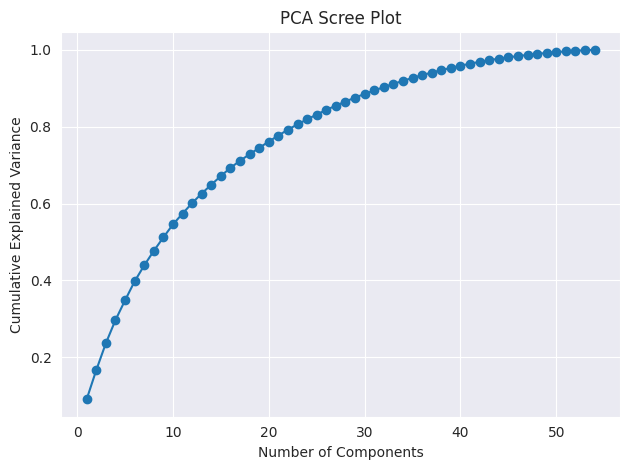

In [46]:
# Perform PCA

# Step 1: PCA
pca = PCA()
pca_result = pca.fit_transform(pivot_df)

# Step 2: Scree plot to decide # of components
explained_var = pca.explained_variance_ratio_
plt.plot(range(1, len(explained_var)+1), explained_var.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.tight_layout()
plt.show()


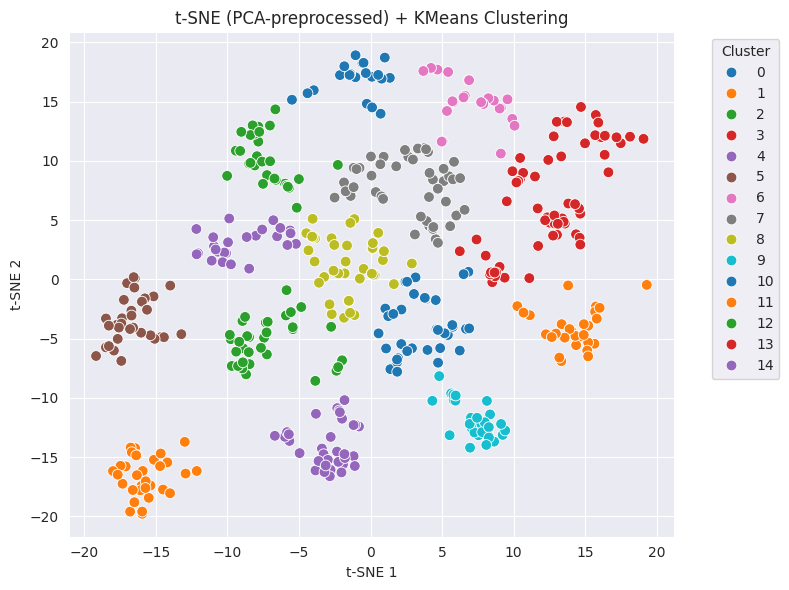

In [56]:
# Step 3: Keep N components based on scree plot
n_components = 22  # Example, pick based on where curve levels off
pca = PCA(n_components=n_components)
pca_reduced = pca.fit_transform(pivot_df)

# Step 4: t-SNE on PCA-reduced data
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(pca_reduced)

# Step 5: KMeans clustering
kmeans = KMeans(n_clusters=15, random_state=42, n_init=30)
cluster_labels = kmeans.fit_predict(tsne_coords)

# Step 6: Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE (PCA-preprocessed) + KMeans Clustering")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Source Monkey Centered vectorization (9-dim)

In [ ]:
%reset
%matplotlib inline
significant_results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/directional_linear_regression_on_single_neurons_low_variance_removed.pkl')
significant_results = significant_results[significant_results['p_value'] < 0.05]

In [ ]:
filtered_df = (
        significant_results
        .sort_values('R-squared', ascending=False)
        .drop_duplicates(['NeuronID', 'Source_Monkey'])
    )
filtered_df = filtered_df.reset_index(drop=True)
# Step 1: pivot (NeuronID × SourceMonkey) wide format....
pivot_df = filtered_df.pivot(index='NeuronID', columns='Source_Monkey', values='R-squared').fillna(0)

# pivot_df[pivot_df < 0.05] = 0
pivot_df = pivot_df[(pivot_df > 0).sum(axis=1) >= 2]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df)
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(scaled_data)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=40, n_init=5)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
cluster_series = pd.Series(cluster_labels)
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels
n_clusters = cluster_series.nunique()
# Figure setup
fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 5), sharey=True)

for i, cluster_id in enumerate(sorted(cluster_series.unique())):
    ax = axes[i] if n_clusters > 1 else axes

    cluster_df = pivot_df_clustered[pivot_df_clustered['Cluster'] == cluster_id].drop(columns='Cluster')
    mean_r2 = cluster_df.mean().sort_values(ascending=True)

    sns.barplot(x=mean_r2.values, y=mean_r2.index, ax=ax, color='blue')
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Mean R²")
    if i == 0:
        ax.set_ylabel("SourceMonkey")
    else:
        ax.set_ylabel("")
    ax.grid(True)

plt.tight_layout()
plt.show()

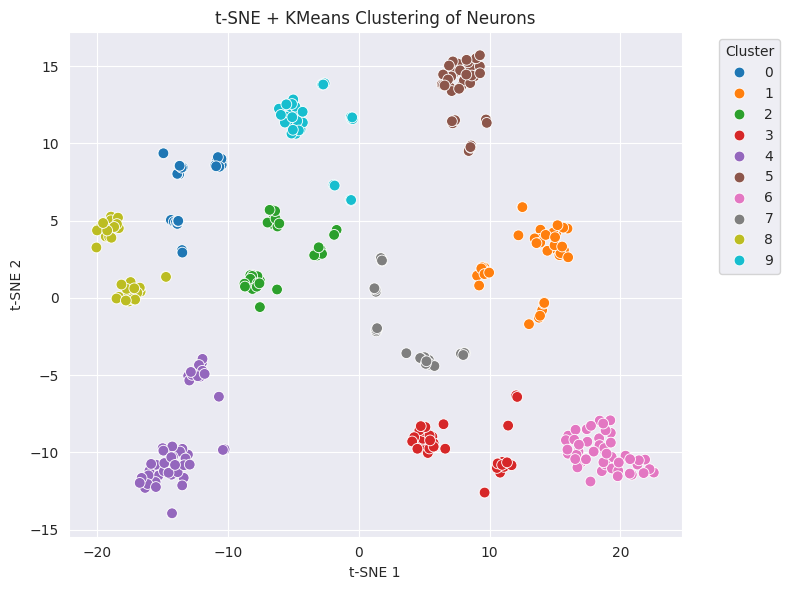

In [57]:
filtered_df = (
        significant_results
        .sort_values('R-squared', ascending=False)
        .drop_duplicates(['NeuronID', 'Behavior'])
    )
filtered_df = filtered_df.reset_index(drop=True)
# Step 1: pivot (NeuronID × Behavior) wide format 만들기
pivot_df = filtered_df.pivot(index='NeuronID', columns='Behavior', values='R-squared').fillna(0)

# pivot_df[pivot_df < 0.05] = 0
pivot_df = pivot_df[(pivot_df > 0).sum(axis=1) >= 2]

# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(pivot_df)
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(pivot_df)

# KMeans clustering
kmeans = KMeans(n_clusters=10, random_state=42, n_init=30)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()